In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


데이터 기본 확인

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


결측지 분석표

In [ ]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": round(df.isnull().mean()*100,2)
})

missing.sort_values(
    "Missing",
    ascending=False
)

,Missing,Percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


결측시 시각화

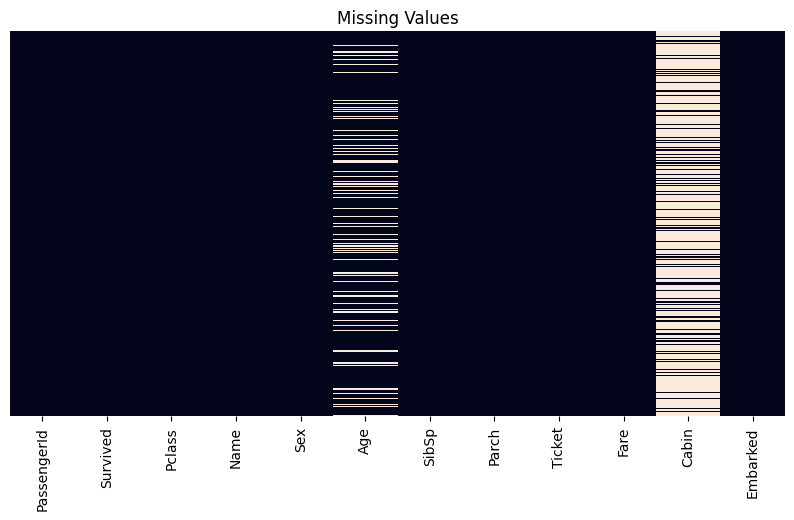

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values")
plt.show()

타겟 변수 확인

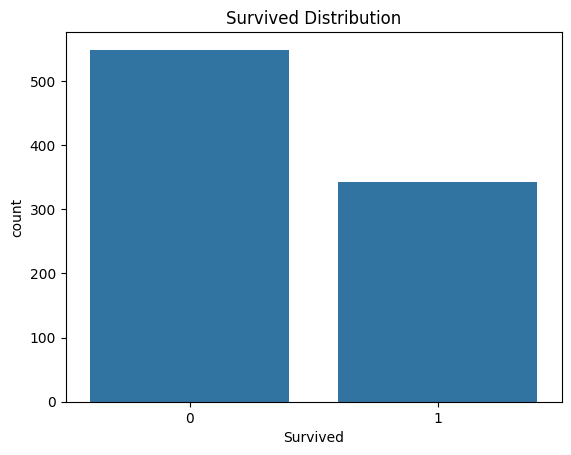

In [ ]:
sns.countplot(
    x='Survived',
    data=df
)

plt.title("Survived Distribution")
plt.show()

Age 분포

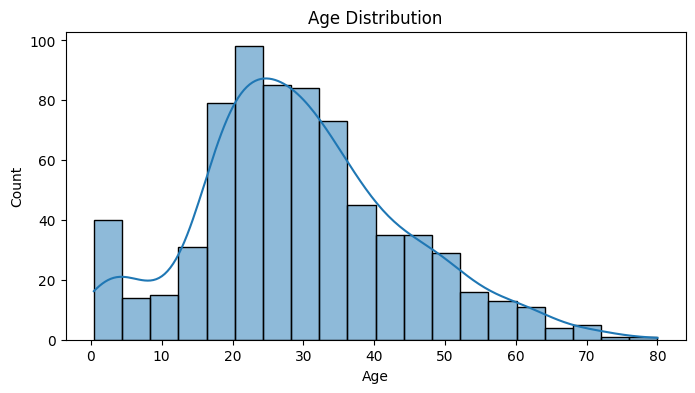

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

Fare 이상치

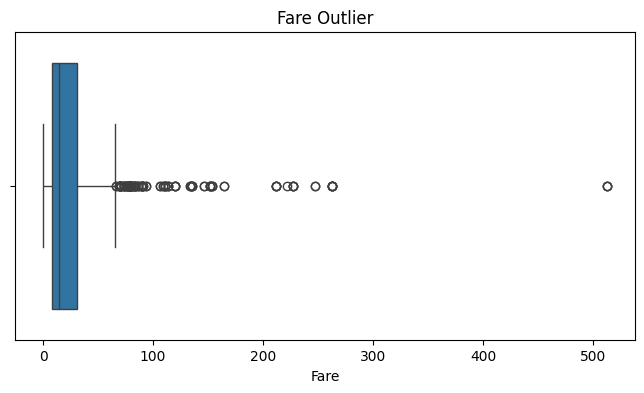

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['Fare']
)

plt.title("Fare Outlier")
plt.show()

상관관계

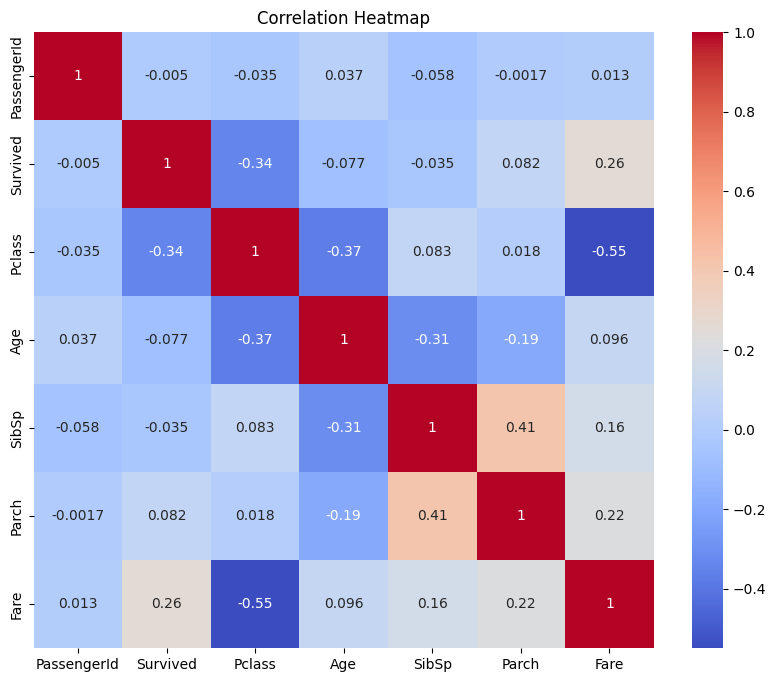

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# FamilySize 생성

In [ ]:
df['FamilySize'] = (
    df['SibSp']
    + df['Parch']
    + 1
)

df[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


가족 규모를 나타내는 변수
형제/배우자 수 + 부모/자녀 수 + 본인

# IsAlone 생성

In [ ]:
df['IsAlone'] = (
    df['FamilySize'] == 1
).astype(int)

df[['FamilySize','IsAlone']].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


혼자 여행했는지 여부
1 = 혼자
0 = 가족 동반

# FarePerPerson 생성

In [ ]:
df['FarePerPerson'] = (
    df['Fare']
    /
    df['FamilySize']
)

df[['Fare','FamilySize','FarePerPerson']].head()

,Fare,FamilySize,FarePerPerson
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000


가족 규모에 따른 1인당 운임

# AgeGroup 생성

In [ ]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,60,100],
    labels=[
        'Child',
        'Teen',
        'Young',
        'Adult',
        'Senior'
    ]
)

df[['Age','AgeGroup']].head()

,Age,AgeGroup
0,22.0,Young
1,38.0,Adult
2,26.0,Young
3,35.0,Young
4,35.0,Young


연속형 Age를 구간화하여
범주형 변수 생성

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,FarePerPerson,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,3.62500,Young
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,35.64165,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,7.92500,Young
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,26.55000,Young
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,8.05000,Young


# 파생변수 시각화


FamilySize

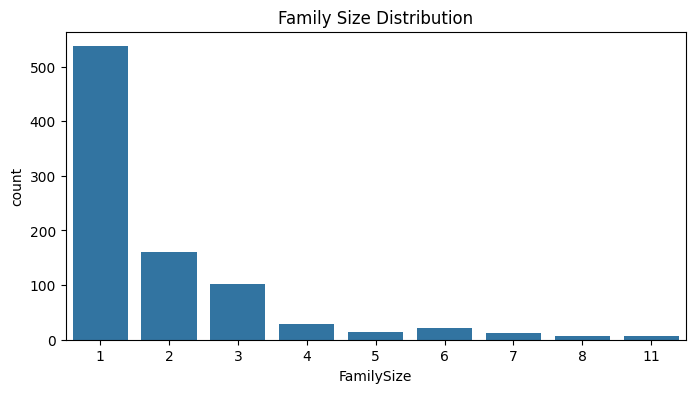

In [ ]:
plt.figure(figsize=(8,4))

sns.countplot(
    x='FamilySize',
    data=df
)

plt.title("Family Size Distribution")
plt.show()

IsAlone

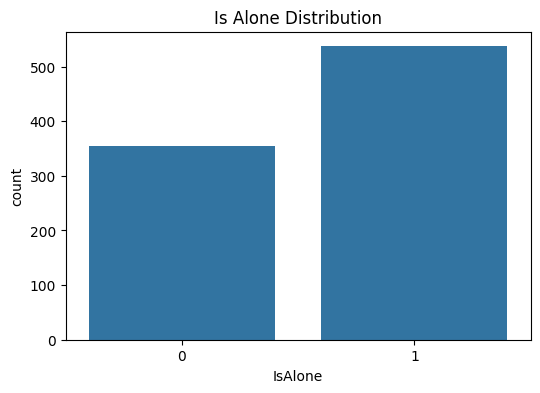

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='IsAlone',
    data=df
)

plt.title("Is Alone Distribution")
plt.show()

AgeGroup

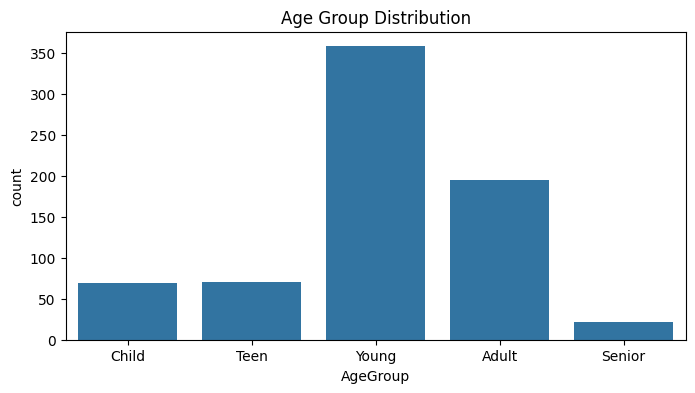

In [ ]:
plt.figure(figsize=(8,4))

sns.countplot(
    x='AgeGroup',
    data=df
)

plt.title("Age Group Distribution")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OrdinalEncoder
)

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
df_model = df.copy()

df_model = df_model.drop(
    columns=[
        'PassengerId',
        'Name',
        'Ticket',
        'Cabin'
    ]
)

# Train/Test Split

In [ ]:
X = df_model.drop(
    'Survived',
    axis=1
)

y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
numeric_features = [
    'Age',
    'Fare',
    'SibSp',
    'Parch',
    'FamilySize',
    'FarePerPerson'
]

categorical_features = [
    'Pclass',
    'Sex',
    'Embarked',
    'AgeGroup',
    'IsAlone'
]

In [ ]:
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy":
        round(
            accuracy_score(
                y_test,
                pred
            ),4
        ),

        "Precision":
        round(
            precision_score(
                y_test,
                pred
            ),4
        ),

        "Recall":
        round(
            recall_score(
                y_test,
                pred
            ),4
        ),

        "F1":
        round(
            f1_score(
                y_test,
                pred
            ),4
        ),

        "ROC-AUC":
        round(
            roc_auc_score(
                y_test,
                prob
            ),4
        )
    }

# Exp1 Mean + OneHot + Standard

In [ ]:
exp1 = ColumnTransformer([

(
'num',

Pipeline([
('imputer',
 SimpleImputer(
 strategy='mean'
 )),

('scaler',
 StandardScaler()
 )
]),

numeric_features
),

(
'cat',

Pipeline([
('imputer',
 SimpleImputer(
 strategy='most_frequent'
 )),

('encoder',
 OneHotEncoder(
 handle_unknown='ignore'
 ))
]),

categorical_features
)

])

In [ ]:
X_train_exp1 = exp1.fit_transform(X_train)

X_test_exp1 = exp1.transform(X_test)

# Exp2 Median + Label + MinMax + Feature Selection

In [ ]:
exp2 = ColumnTransformer([

(
'num',

Pipeline([
('imputer',
 SimpleImputer(
 strategy='median'
 )),

('scaler',
 MinMaxScaler()
 )
]),

numeric_features
),

(
'cat',

Pipeline([
('imputer',
 SimpleImputer(
 strategy='most_frequent'
 )),

('encoder',
 OrdinalEncoder()
 )
]),

categorical_features
)

])

In [ ]:
X_train_exp2 = exp2.fit_transform(X_train)

X_test_exp2 = exp2.transform(X_test)

In [ ]:
selector2 = SelectKBest(
    mutual_info_classif,
    k=8
)

X_train_exp2 = selector2.fit_transform(
    X_train_exp2,
    y_train
)

X_test_exp2 = selector2.transform(
    X_test_exp2
)

# Exp3 Most Frequent + OneHot + Robust + Feature Selection

In [ ]:
exp3 = ColumnTransformer([

(
'num',

Pipeline([
('imputer',
 SimpleImputer(
 strategy='most_frequent'
 )),

('scaler',
 RobustScaler()
 )
]),

numeric_features
),

(
'cat',

Pipeline([
('imputer',
 SimpleImputer(
 strategy='most_frequent'
 )),

('encoder',
 OneHotEncoder(
 handle_unknown='ignore'
 ))
]),

categorical_features
)

])

In [ ]:
X_train_exp3 = exp3.fit_transform(X_train)

X_test_exp3 = exp3.transform(X_test)

In [ ]:
selector3 = SelectKBest(
    mutual_info_classif,
    k=10
)

X_train_exp3 = selector3.fit_transform(
    X_train_exp3,
    y_train
)

X_test_exp3 = selector3.transform(
    X_test_exp3
)

In [ ]:
results = []

In [ ]:
experiments = {

'Exp1':
(
X_train_exp1,
X_test_exp1
),

'Exp2':
(
X_train_exp2,
X_test_exp2
),

'Exp3':
(
X_train_exp3,
X_test_exp3
)

}

In [ ]:
models = {

'Logistic Regression':
LogisticRegression(
    max_iter=1000
),

'Random Forest':
RandomForestClassifier(
    random_state=42
)

}

In [ ]:
for exp_name,(xtr,xts) in experiments.items():

    for model_name,model in models.items():

        result = evaluate_model(
            model,
            xtr,
            xts,
            y_train,
            y_test
        )

        result['Experiment'] = exp_name
        result['Model'] = model_name

        results.append(result)

In [ ]:
result_df = pd.DataFrame(results)

result_df = result_df[
[
'Experiment',
'Model',
'Accuracy',
'Precision',
'Recall',
'F1',
'ROC-AUC'
]
]

result_df.sort_values(
    'Accuracy',
    ascending=False
)

,Experiment,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Exp1,Logistic Regression,0.8268,0.8276,0.6957,0.7559,0.8607
1,Exp1,Random Forest,0.8268,0.7969,0.7391,0.7669,0.8316
5,Exp3,Random Forest,0.8156,0.7647,0.7536,0.7591,0.8321
3,Exp2,Random Forest,0.8045,0.7576,0.7246,0.7407,0.8108
4,Exp3,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8433
2,Exp2,Logistic Regression,0.7989,0.7797,0.6667,0.7188,0.8462
